<a href="https://colab.research.google.com/github/Bright099/MachineLearning/blob/main/neuraltests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
data = load_breast_cancer()

X = data.data
y = data.target

y = y.reshape(-1, 1)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (455, 30)
X_test: (114, 30)
y_train: (455, 1)
y_test: (114, 1)


In [9]:
m, n_features = X_train.shape

W = np.random.randn(n_features, 1) * 0.01
b = np.zeros((1, 1))

print(W.shape)
print(b.shape)

(30, 1)
(1, 1)


In [10]:
def sigmoid(z):
  return 1/(1 + np.exp(-z))
z = np.array([[0], [2], [-2]])
print(sigmoid(z))

[[0.5       ]
 [0.88079708]
 [0.11920292]]


In [13]:
Z = X_train.dot(W) + b

A = sigmoid(Z)
A.shape

(455, 1)

In [14]:
def compute_loss(y, A):
  m = y.shape[0]
  epsilon = 1e-15

  A = np.clip(A, epsilon, 1 - epsilon)

  loss = -(1/m) * np.sum(y * np.log(A) + (1 - y) * np.log(1-A))
  return loss

In [15]:
loss = compute_loss(y_train, A)
print(loss)

0.6639450027756294


In [16]:
# Hyperparameters
learning_rate = 0.01
epochs = 2000

losses = []

for epoch in range(epochs):
  #Forward pass
  Z = np.dot(X_train, W) + b
  A = sigmoid(Z)

  # loss
  loss = compute_loss(y_train, A)
  losses.append(loss)

  # backpropagation
  dZ = A - y_train
  dW = (1/m) * np.dot(X_train.T, dZ)
  db = (1/m) * np.sum(dZ, keepdims=True)

  #Update Parameters
  W = W - learning_rate * dW
  b = b - learning_rate * db

  #Print progress
  if epoch % 100 == 0:
    print(f"Epoch {epoch}, Loss: {loss}")

Epoch 0, Loss: 0.6639450027756294
Epoch 100, Loss: 0.25307485546455316
Epoch 200, Loss: 0.1913029484223063
Epoch 300, Loss: 0.16309667551076068
Epoch 400, Loss: 0.14629738208144683
Epoch 500, Loss: 0.13490212305330054
Epoch 600, Loss: 0.12654131901147658
Epoch 700, Loss: 0.12007698360846482
Epoch 800, Loss: 0.11488888419701972
Epoch 900, Loss: 0.11060731693549332
Epoch 1000, Loss: 0.10699669213316831
Epoch 1100, Loss: 0.10389892117680462
Epoch 1200, Loss: 0.10120346923472852
Epoch 1300, Loss: 0.09883042301372816
Epoch 1400, Loss: 0.09672038538671866
Epoch 1500, Loss: 0.09482816811260945
Epoch 1600, Loss: 0.0931187038690645
Epoch 1700, Loss: 0.09156431008840175
Epoch 1800, Loss: 0.09014280605736577
Epoch 1900, Loss: 0.088836185500807


In [17]:
# Predict on test set
Z_test = np.dot(X_test, W) + b
A_test = sigmoid(Z_test)

y_pred = (A_test >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9912280701754386
[[42  1]
 [ 0 71]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        43
           1       0.99      1.00      0.99        71

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



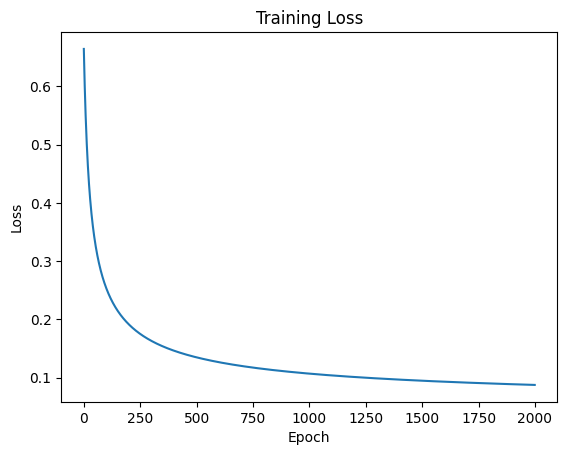

In [18]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()